**Fase #0:** Librerías y configuración

In [1]:
!pip install kmodes prince -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from kmodes.kprototypes import KPrototypes
import prince

pd.set_option('display.float_format', lambda x: '%.4f' % x)
RANDOM_STATE = 42

**Fase #1:** Carga de datos

In [2]:
# Fuente: UCI Automobile Dataset (id=10), subido a mi propio repositorio
# https://github.com/gabrielbaquez-max/UCI
col_names = ['symboling','normalized-losses','make','fuel-type','aspiration','num-of-doors',
             'body-style','drive-wheels','engine-location','wheel-base','length','width','height',
             'curb-weight','engine-type','num-of-cylinders','engine-size','fuel-system','bore',
             'stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price']

df = pd.read_csv('https://raw.githubusercontent.com/gabrielbaquez-max/UCI/main/imports-85.data',
                  names=col_names, na_values='?')

print(df.shape)
df.head()

(205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6000,...,130,mpfi,3.4700,2.6800,9.0000,111.0000,5000.0000,21,27,13495.0000
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6000,...,130,mpfi,3.4700,2.6800,9.0000,111.0000,5000.0000,21,27,16500.0000
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5000,...,152,mpfi,2.6800,3.4700,9.0000,154.0000,5000.0000,19,26,16500.0000
3,2,164.0000,audi,gas,std,four,sedan,fwd,front,99.8000,...,109,mpfi,3.1900,3.4000,10.0000,102.0000,5500.0000,24,30,13950.0000
4,2,164.0000,audi,gas,std,four,sedan,4wd,front,99.4000,...,136,mpfi,3.1900,3.4000,8.0000,115.0000,5500.0000,18,22,17450.0000


**Fase #2:** Preprocesamiento

In [3]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in df.columns if c not in cat_cols]

print("Categóricas:", cat_cols)
print("Numéricas:", num_cols)
print("\nNulos por columna:\n", df.isna().sum()[df.isna().sum() > 0])

# A diferencia del dataset de votos (donde NaN = "abstención", una categoría informativa),
# aquí el NaN es un dato faltante real. Por eso imputamos en vez de crear "_??":
# mediana para numéricas, moda para categóricas.
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print("\nNulos tras imputación:", df.isna().sum().sum())

Categóricas: ['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']
Numéricas: ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

Nulos por columna:
 normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64

Nulos tras imputación: 0


**Fase #3:** Preparación de las 3 metodologías a comparar

In [4]:
# --- Espacio de evaluación común (SOLO para medir Silhouette de forma comparable) ---
# Todas las metodologías producen particiones distintas sobre los mismos 205 autos;
# para comparar "peras con peras" evaluamos todas sobre la misma representación
# numérica completa: variables escaladas + categóricas en One-Hot.
ohe_eval = OneHotEncoder(sparse_output=False, drop='if_binary')
X_cat_ohe = ohe_eval.fit_transform(df[cat_cols])
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df[num_cols])
X_eval = np.hstack([X_num_scaled, X_cat_ohe])
print("Espacio de evaluación:", X_eval.shape)

# --- Insumos para K-Prototypes: datos mixtos crudos, con índice de columnas categóricas ---
df_mixed = df[num_cols + cat_cols].copy()  # numéricas primero, categóricas después
cat_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

# --- Insumo para K-Means + MCA: componentes MCA de categóricas + numéricas escaladas ---
mca = prince.MCA(n_components=5, random_state=RANDOM_STATE)
X_cat_mca = mca.fit_transform(df[cat_cols]).values
X_mca_full = np.hstack([X_num_scaled, X_cat_mca])

Espacio de evaluación: (205, 72)


**Fase #4:** Barrido de k y comparación de silueta entre las 3 metodologías

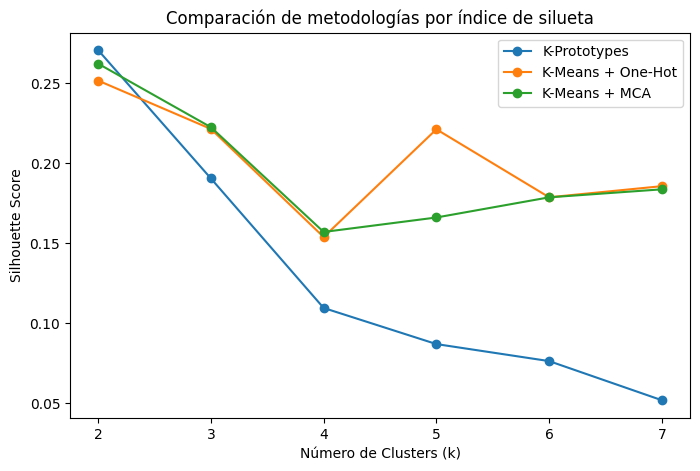

 k  K-Prototypes  K-Means+OneHot  K-Means+MCA
 2        0.2708          0.2518       0.2624
 3        0.1906          0.2216       0.2226
 4        0.1096          0.1540       0.1572
 5        0.0871          0.2214       0.1662
 6        0.0764          0.1789       0.1788
 7        0.0520          0.1858       0.1838


In [5]:
ks = range(2, 8)
sil_kproto, sil_ohe, sil_mca = [], [], []

for k in ks:
    # A) K-Prototypes: trata numéricas y categóricas por separado (K-Means + K-Modes)
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=5, random_state=RANDOM_STATE, verbose=0)
    lab_a = kproto.fit_predict(df_mixed.values, categorical=cat_idx)
    sil_kproto.append(silhouette_score(X_eval, lab_a))

    # B) K-Means sobre One-Hot Encoding
    lab_b = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_eval).labels_
    sil_ohe.append(silhouette_score(X_eval, lab_b))

    # C) K-Means sobre MCA (categóricas) + numéricas escaladas
    lab_c = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_mca_full).labels_
    sil_mca.append(silhouette_score(X_eval, lab_c))

plt.figure(figsize=(8, 5))
plt.plot(list(ks), sil_kproto, marker='o', label='K-Prototypes')
plt.plot(list(ks), sil_ohe, marker='o', label='K-Means + One-Hot')
plt.plot(list(ks), sil_mca, marker='o', label='K-Means + MCA')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Comparación de metodologías por índice de silueta')
plt.legend()
plt.show()

resumen = pd.DataFrame({'k': list(ks), 'K-Prototypes': sil_kproto,
                         'K-Means+OneHot': sil_ohe, 'K-Means+MCA': sil_mca})
print(resumen.to_string(index=False))

**Fase #5:** Selección de metodología y k ganadores

In [6]:
mejor_k = resumen.set_index('k')[['K-Prototypes','K-Means+OneHot','K-Means+MCA']].stack().idxmax()
print(f"Mejor combinación (k, metodología): {mejor_k}  -> Silhouette = {resumen.set_index('k').loc[mejor_k[0], mejor_k[1]]:.4f}")

Mejor combinación (k, metodología): (np.int64(2), 'K-Prototypes')  -> Silhouette = 0.2708


**Fase #6:** Entrenamiento del modelo final

In [7]:
kproto_final = KPrototypes(n_clusters=2, init='Cao', n_init=10, random_state=RANDOM_STATE, verbose=0)
labels = kproto_final.fit_predict(df_mixed.values, categorical=cat_idx)
df['Cluster'] = labels
df['Cluster'].value_counts()

,count
Cluster,
1,180
0,25


**Fase #7:** Caracterización de clusters (test values)

In [8]:
def test_value_continuous(group_mean, overall_mean, empirical_variance, n_total, n_group):
    numerator = group_mean - overall_mean
    denominator = np.sqrt(((n_total - n_group) / (n_total - 1)) * (empirical_variance / n_group))
    return numerator / denominator

def test_value_categorical(n_ij, n_j, n_group, n_total):
    expected = (n_group * n_j) / n_total
    numerator = n_ij - expected
    denominator = np.sqrt(((n_total - n_group) / (n_total - 1)) * (1 - (n_j / n_total)) * ((n_group * n_j) / n_total))
    return numerator / denominator

def calculate_test_values(df, inputs, target):
    results = []
    n_total = len(df)
    for group in df[target].unique():
        df_group = df[df[target] == group]
        n_group = len(df_group)
        for inp in inputs:
            if pd.api.types.is_numeric_dtype(df[inp]):
                tv = test_value_continuous(df_group[inp].mean(), df[inp].mean(),
                                            df[inp].var(ddof=1), n_total, n_group)
                results.append({'Type': 'continuous', 'Attribute': inp, 'Group': group,
                                 'Test Value': tv, 'Group Mean': df_group[inp].mean(),
                                 'Overall Mean': df[inp].mean()})
            else:
                vc, gvc = df[inp].value_counts(), df_group[inp].value_counts()
                for cat in vc.index:
                    n_ij, n_j = gvc.get(cat, 0), vc[cat]
                    tv = test_value_categorical(n_ij, n_j, n_group, n_total)
                    results.append({'Type': 'categorical', 'Attribute': f'{inp}={cat}', 'Group': group,
                                     'Test Value': tv, 'Group Mean': n_ij / n_group, 'Overall Mean': n_j / n_total})
    return pd.DataFrame(results)

tv = calculate_test_values(df, num_cols + cat_cols, 'Cluster')
for i in sorted(tv['Group'].unique()):
    print(f"\nCluster {i} (n={len(df[df['Cluster'] == i])}):")
    sub = tv[(tv['Group'] == i) & (tv['Test Value'].abs() >= 2)].sort_values('Test Value', ascending=False)
    display(sub[['Attribute', 'Test Value', 'Group Mean', 'Overall Mean']].head(10))


Cluster 0 (n=25):


,Attribute,Test Value,Group Mean,Overall Mean
91,price,11.7785,30585.1200,13150.3073
83,engine-size,9.8338,203.8400,126.9073
82,curb-weight,8.1272,3350.5600,2555.5659
102,make=mercedes-benz,7.7231,0.3200,0.0390
80,width,7.3650,68.8760,65.9078
87,horsepower,7.2545,158.0400,104.1659
138,num-of-cylinders=six,6.6709,0.5200,0.1171
126,drive-wheels=rwd,6.4940,0.9600,0.3707
79,length,6.1933,188.4040,174.0493
78,wheel-base,5.8512,105.3760,98.7566



Cluster 1 (n=180):


,Attribute,Test Value,Group Mean,Overall Mean
61,num-of-cylinders=four,8.8755,0.8722,0.7756
14,highway-mpg,6.3005,31.8833,30.7512
49,drive-wheels=fwd,5.8924,0.6611,0.5854
13,city-mpg,5.8740,26.2222,25.2195
52,engine-location=front,4.6705,1.0000,0.9854
69,fuel-system=2bbl,3.6679,0.3667,0.3220
45,body-style=hatchback,3.3839,0.3833,0.3415
16,make=toyota,2.2893,0.1778,0.1561
44,body-style=sedan,-2.2583,0.4389,0.4683
66,num-of-cylinders=twelve,-2.6833,0.0000,0.0049


**Fase #8:** Conclusión comparativa

In [9]:
conclusion = pd.DataFrame({
    'Criterio': ['Tipo de dato soportado nativamente', 'Transformación previa requerida',
                 'k óptimo', 'Mejor Silhouette obtenido', 'Interpretabilidad'],
    'K-Prototypes': ['Numéricas + categóricas por separado (sin forzar)', 'Ninguna', 2, round(max(sil_kproto), 4),
                      'Alta: usa las categorías originales, no columnas OHE'],
    'K-Means + OneHot': ['Solo numéricas (fuerza categóricas a binarias)', 'One-Hot Encoding', 5, round(max(sil_ohe), 4),
                          'Media: columnas binarias por categoría'],
    'K-Means + MCA': ['Solo numéricas (proyecta categóricas)', 'MCA + concatenar con numéricas', 6, round(max(sil_mca), 4),
                       'Baja: componentes MCA sin significado directo'],
})
conclusion

,Criterio,K-Prototypes,K-Means + OneHot,K-Means + MCA
0,Tipo de dato soportado nativamente,Numéricas + categóricas por separado (sin forzar),Solo numéricas (fuerza categóricas a binarias),Solo numéricas (proyecta categóricas)
1,Transformación previa requerida,Ninguna,One-Hot Encoding,MCA + concatenar con numéricas
2,k óptimo,2,5,6
3,Mejor Silhouette obtenido,0.2708,0.2518,0.2624
4,Interpretabilidad,"Alta: usa las categorías originales, no column...",Media: columnas binarias por categoría,Baja: componentes MCA sin significado directo
